Generating Graph 1: Domain Shift Heatmap...


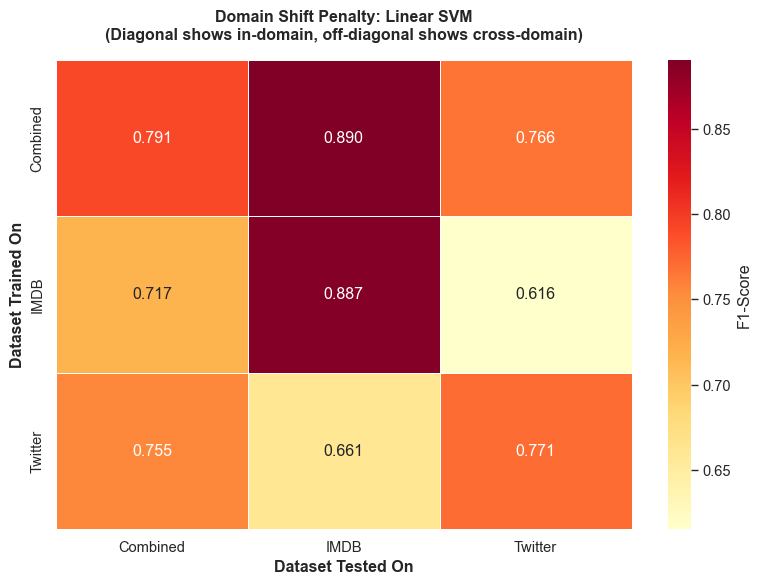

Generating Graph 2: Linear vs Kernel Algorithm Showdown...


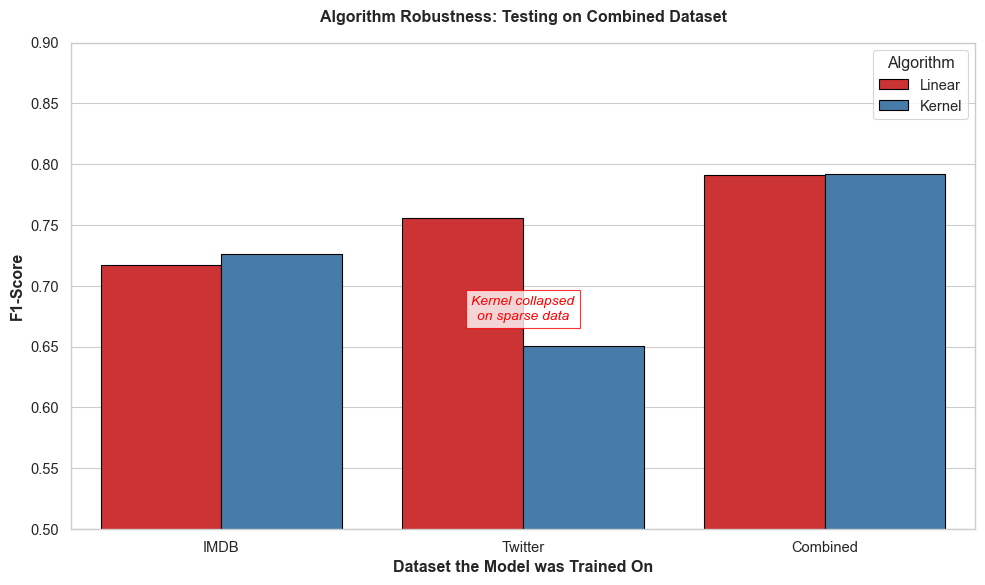

Generating Graph 3: Precision vs Recall Trade-off...


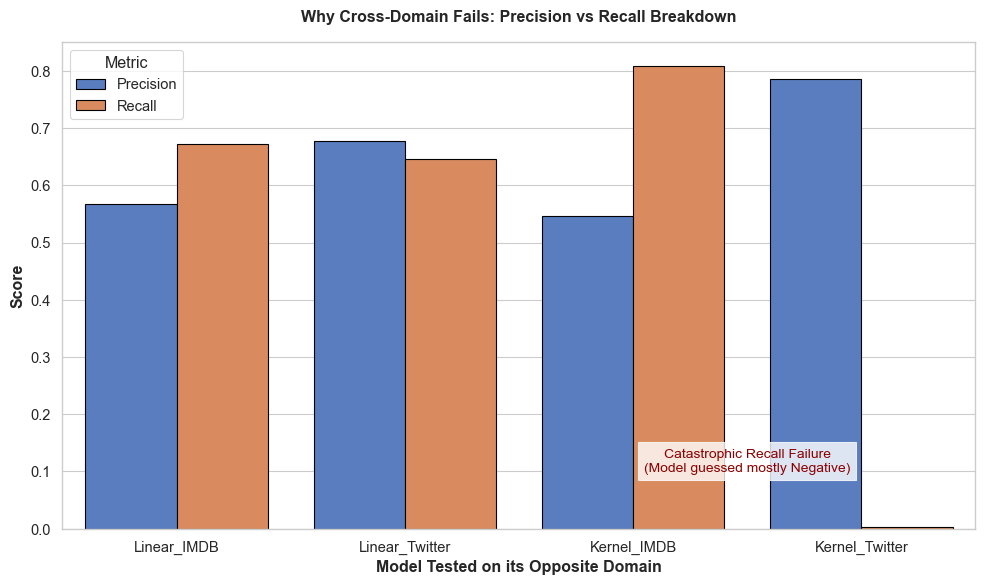

Generating Graph 4: Ultimate Model Profile...


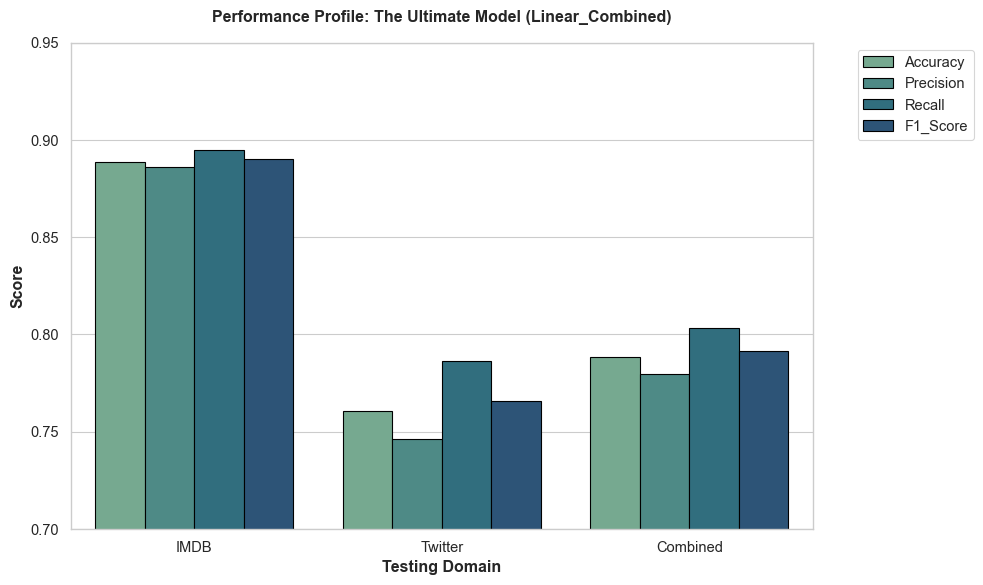


Success! All graphs have been rendered and saved to the ./outputs/ folder.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import io
import os

# Create an output directory for the saved graphs
os.makedirs('./outputs', exist_ok=True)

# 1. Load the exact data you generated (embedded for easy execution)
csv_data = """Model,Tested_On,Accuracy,Precision,Recall,F1_Score,Macro_F1
Linear_IMDB,IMDB,0.8856,0.8798,0.8952,0.8874,0.8855
Linear_IMDB,Twitter,0.5823,0.5678,0.6721,0.6156,0.5792
Linear_IMDB,Combined,0.7000,0.6770,0.7627,0.7173,0.6988
Linear_Twitter,IMDB,0.6659,0.6765,0.6457,0.6607,0.6658
Linear_Twitter,Twitter,0.7656,0.7510,0.7913,0.7706,0.7655
Linear_Twitter,Combined,0.7547,0.7520,0.7588,0.7554,0.7547
Linear_Combined,IMDB,0.8888,0.8858,0.8946,0.8902,0.8887
Linear_Combined,Twitter,0.7607,0.7463,0.7863,0.7658,0.7605
Linear_Combined,Combined,0.7885,0.7797,0.8032,0.7913,0.7884
Kernel_IMDB,IMDB,0.8682,0.8609,0.8807,0.8707,0.8681
Kernel_IMDB,Twitter,0.5712,0.5467,0.8092,0.6526,0.5463
Kernel_IMDB,Combined,0.6829,0.6383,0.8417,0.7260,0.6748
Kernel_Twitter,IMDB,0.4969,0.7857,0.0021,0.0043,0.3338
Kernel_Twitter,Twitter,0.7565,0.7435,0.7798,0.7612,0.7565
Kernel_Twitter,Combined,0.7035,0.7909,0.5518,0.6501,0.6964
Kernel_Combined,IMDB,0.8850,0.8811,0.8920,0.8865,0.8849
Kernel_Combined,Twitter,0.7737,0.7559,0.8051,0.7797,0.7735
Kernel_Combined,Combined,0.7879,0.7757,0.8092,0.7921,0.7879"""

df = pd.read_csv(io.StringIO(csv_data))

# Extract Algorithm and Trained_On for easier plotting
df[['Algorithm', 'Trained_On']] = df['Model'].str.split('_', expand=True)

# Set global seaborn styling for academic reports
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# =========================================================
# GRAPH 1: The Domain Shift Heatmap (F1-Score)
# =========================================================
print("Generating Graph 1: Domain Shift Heatmap...")
df_linear = df[df['Algorithm'] == 'Linear']
heatmap_data = df_linear.pivot(index='Trained_On', columns='Tested_On', values='F1_Score')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'F1-Score'})
plt.title("Domain Shift Penalty: Linear SVM\n(Diagonal shows in-domain, off-diagonal shows cross-domain)", pad=15, fontweight='bold')
plt.ylabel("Dataset Trained On", fontweight='bold')
plt.xlabel("Dataset Tested On", fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/1_domain_shift_heatmap.png', dpi=300)
plt.show()

# =========================================================
# GRAPH 2: Linear vs Kernel - The Combined Test Showdown
# =========================================================
print("Generating Graph 2: Linear vs Kernel Algorithm Showdown...")
df_combined_test = df[df['Tested_On'] == 'Combined']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_combined_test, x='Trained_On', y='F1_Score', hue='Algorithm', palette='Set1', edgecolor='black')
plt.title("Algorithm Robustness: Testing on Combined Dataset", pad=15, fontweight='bold')
plt.ylabel("F1-Score", fontweight='bold')
plt.xlabel("Dataset the Model was Trained On", fontweight='bold')
plt.ylim(0.5, 0.9) # Zoom in to see the differences

# Add a warning label for the Kernel Twitter collapse
plt.text(1, 0.67, 'Kernel collapsed\non sparse data', color='red', ha='center', va='bottom', fontsize=10, style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

plt.tight_layout()
plt.savefig('./outputs/2_algorithm_comparison.png', dpi=300)
plt.show()

# =========================================================
# GRAPH 3: Precision vs. Recall (The Failure Breakdown)
# =========================================================
print("Generating Graph 3: Precision vs Recall Trade-off...")
# We melt the dataframe to plot Precision and Recall side-by-side
df_metrics = df.melt(id_vars=['Model', 'Algorithm', 'Trained_On', 'Tested_On'], 
                     value_vars=['Precision', 'Recall'], 
                     var_name='Metric', value_name='Score')

# Let's look specifically at models tested on the opposite domain
opposite_domain = df_metrics[((df_metrics['Trained_On'] == 'IMDB') & (df_metrics['Tested_On'] == 'Twitter')) | 
                             ((df_metrics['Trained_On'] == 'Twitter') & (df_metrics['Tested_On'] == 'IMDB'))]

plt.figure(figsize=(10, 6))
sns.barplot(data=opposite_domain, x='Model', y='Score', hue='Metric', palette='muted', edgecolor='black')
plt.title("Why Cross-Domain Fails: Precision vs Recall Breakdown", pad=15, fontweight='bold')
plt.ylabel("Score", fontweight='bold')
plt.xlabel("Model Tested on its Opposite Domain", fontweight='bold')

plt.text(2.5, 0.1, 'Catastrophic Recall Failure\n(Model guessed mostly Negative)', color='darkred', ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('./outputs/3_precision_recall_gap.png', dpi=300)
plt.show()

# =========================================================
# GRAPH 4: Profile of the Ultimate Model (Linear_Combined)
# =========================================================
print("Generating Graph 4: Ultimate Model Profile...")
df_ultimate = df[df['Model'] == 'Linear_Combined'].melt(
    id_vars=['Tested_On'], 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1_Score'], 
    var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_ultimate, x='Tested_On', y='Score', hue='Metric', palette='crest', edgecolor='black')
plt.title("Performance Profile: The Ultimate Model (Linear_Combined)", pad=15, fontweight='bold')
plt.ylabel("Score", fontweight='bold')
plt.xlabel("Testing Domain", fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.ylim(0.7, 0.95) # Zoom in for detail

plt.tight_layout()
plt.savefig('./outputs/4_ultimate_model_profile.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! All graphs have been rendered and saved to the ./outputs/ folder.")